# Introduction: Tree Based Methods

In this workshop, we discuss tree-based methods for regression and classification. Regression tree methods are used when we have a continuous outcome variable and classification tree methods are used when we are modelling a categorical outcome variable. 
We are going to cover the concepts of tree based methods including:
- Regression trees
- Classification trees
- Random Forests
- Gradient Boosting
- Conclusion: regression vs tree-based methods

Tree based methods involve stratifying / segmenting the predictor space into subregions by using the mean (regression trees) or the mode (classification trees) of the response variable for the training observations in the regions to which it belongs.  
  
Examples are illustrated in Python. 

## Statistical Modelling

Suppose we observe some response, $Y$, and a set of $p$ predictors, $X = (X_1, X_2, \ldots, X_p)$.

Additionally, suppose we believe there is some relationship between $Y$ and $X$.

In general we could express this relationship as
$$
  Y = f(X) + \epsilon,
$$

where:

- $f(\cdot)$ is some fixed but unknown function, 
- $\epsilon$ is a random error independent of $X$.

Here $f(\cdot)$ represents the systematic information about $Y$ provided by $X$.

Knowledge of the true $f(\cdot)$ is almost certainly unavailable, but given a set of observations we
can estimate it.

## Regression trees: $Y$ continuous

To build the sub-regions of the feature space based on the mean value of the response variable the method starts by: 

1- Dividing the predictor space $k-$ distinct non-overlapping regions, say $R_1, R_2, \dots, R_k$

2- For each observation that falls in the region $R_k$ we calculate the mean of the reponse values for the training observations in $R_k$

Now the problem is reduced into an optimisation problem where we are interested to find the subregions $R_1, R_2, \dots, R_k$ that minimise the Residual Sum of Squares: 

$$\sum_{k=1}^K \sum_{i \in R_k} (y_i - \hat{y}_{R_k})^2 $$


where $\hat{y}_{R_k}$ is the mean response of the training observations corresponding to $k-$th region. 

To illistrate this method in python we use sklearn package with diabetes dataset:

Y: is a quantitative measure of disease progression one year after baseline

X:
  - age in years
  - sex
  - bmi body mass index
  - bp average blood pressure
  - s1 tc, total serum cholesterol
  - s2 ldl, low-density lipoproteins
  - s3 hdl, high-density lipoproteins
  - s4 tch, total cholesterol / HDL
  - s5 ltg, log TG (a type of fat found in the blood)
  - s6 glu, blood sugar level
 

In [115]:
# Simple example: regression tree "measure of disease" and "blood pressure"
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import load_diabetes

# Load data as DataFrame
diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2)

# Extract bp column
X_train_bp = X_train["bp"].to_numpy().reshape(-1, 1)
X_test_bp  = X_test["bp"].to_numpy().reshape(-1, 1)

# Fit tree
model = DecisionTreeRegressor(max_depth=3)
model.fit(X_train_bp, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


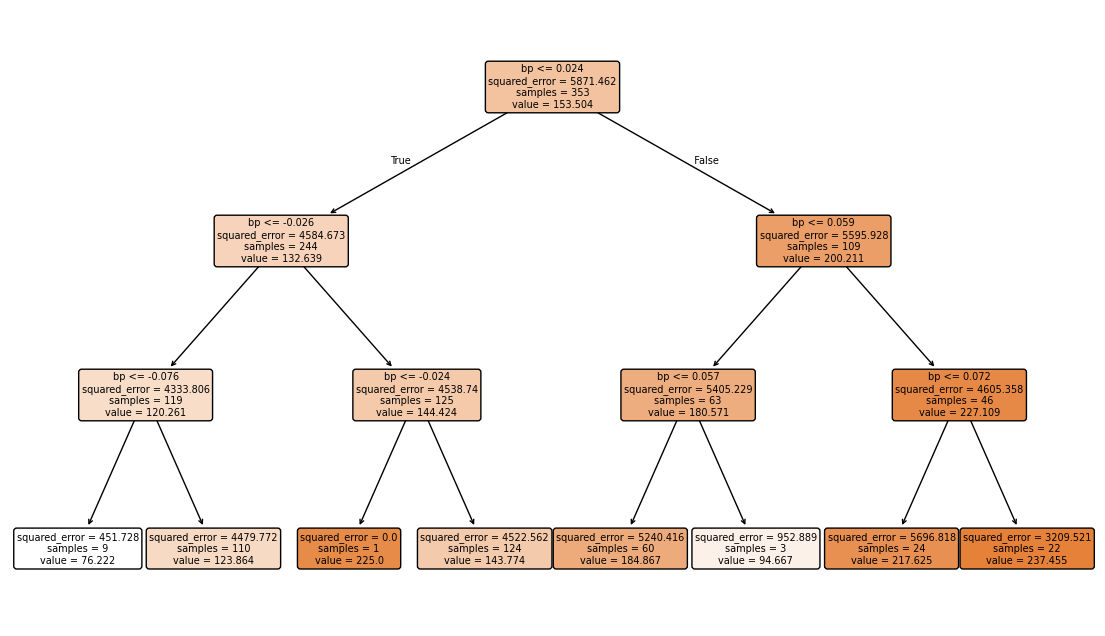

In [116]:
# plot tree
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
tree.plot_tree(
    model,
    feature_names=["bp"],
    filled=True,
    rounded=True
)
plt.show()


In [50]:
# full model
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame = True)
X = diabetes.data  
y = diabetes.target  
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = DecisionTreeRegressor()
mod = model.fit(X_train, y_train)

In [52]:
# The performance of the model 
# import the metrics of interest 
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
y_pred = mod.predict(X_test)

# Mean Squared Error (MSE) 
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error (RMSE): 
rmse = np.sqrt(mse) 

# Mean Absolute Error (MAE) 
mae = mean_absolute_error(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.3f}")

Root Mean Squared Error (RMSE): 86.948
Mean Absolute Error (MAE): 65.888


## Clasiffication trees: $Y$ categorical

For a classification tree we predict that each observation belongs to the most commonly occurring class of training observations in the regions to which it belongs. Because we are dealing with a categorical outcome we can't use the RSS as an optimisation metric. 

Instead, *Gini index* is used 

$$G = \sum_{k=1}^{K} \hat p_{mk}(1-\hat p_{mk})$$

where $\hat p_{mk}$ is the proportion of training observations in the $m$-th region that are from $k$-th class. *Gini index* is a measure of the total variance across $K$ classes. In other words, this is a measure of region *purity*, a small value indicates that the region contains observartions from a single class.

As an example we consider the wine dataset, which is the results of a chemical analysis of wines grown in the same region in Italy by three different cultivators. There are thirteen different measurements taken for different constituents found in the three types of wine.

X: 
 - Alcohol
 - Malic acid
 - Ash
 - Alcalinity of ash
 - Magnesium
 - Total phenols
 - Flavanoids
 - Nonflavanoid phenols
 - Proanthocyanins
 - Color intensity
 - Hue

Y: wine type, with three categories.

In [118]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame= True)
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [119]:
from sklearn.metrics import ConfusionMatrixDisplay

model = tree.DecisionTreeClassifier()
model = model.fit(X_wine_train, y_wine_train)

After fitting a model we can examine diagnostics such as a confusion matrix:

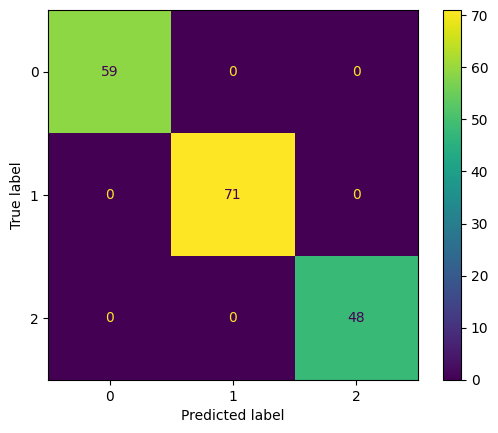

In [120]:
ConfusionMatrixDisplay.from_predictions(y_wine_train, model.predict(X_wine_train))

## Bagging

Methods we discussed above suffer from the high variance, which is when we fit the model in some new data, the results might look completely different. To address this issue, *bagging* techniques can be used. The procedure involves generating several *bootstrap* samples from the original dataset and average among those. 

In this way, we can simulate $B$ samples from the training data and build $B$ regression trees, and then average them. In this way we can reduce the variance which a single tree can have.  


## Random Forests

*Random forests* method work like *bagging* but with a small change that they decorrelate the trees. When we perform a decision tree all predictor variables are considered and the cutpoint is chosen by minimising the *RSS* metric. 
But when building a random forest only a subset of feature space is considered, usually $\sqrt{(p)}$, where $p$ is the number of predictors. 

So we can reduce further the variance by forcing every split to consider only a subset of predictors, so all predictors have more change to be included. 

In [112]:
from sklearn.ensemble import RandomForestRegressor
diabetes = load_diabetes(as_frame = True)
X = diabetes.data  
y = diabetes.target  
#diabetes.feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestRegressor() 
mod = model.fit(X_train, y_train)

y_pred = mod.predict(X_test)

# Mean Squared Error (MSE) 
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error (RMSE): 
rmse = np.sqrt(mse) 

# Mean Absolute Error (MAE) 
mae = mean_absolute_error(y_test, y_pred)


print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.3f}")

Root Mean Squared Error (RMSE): 59.839
Mean Absolute Error (MAE): 49.066


## Boosting

The procedure behind *boosting* method is that the trees are grown sequentially and each tree is grown by using information from the previous tree. In *bagging* trees were generated from independent boostrap samples. So instead of fitting the tree into the training data, the mehtods uses the residual term to fit the model, and the residuals are updated for each step of growing trees. The algorithm is controlled by the parameters: 

- number of trees
- shrinkage parameter that help to include different shaped trees when the residuals are updated at each stage
- number of nodes in each tree


## Variable Importance Measures
Often the interpretation of bagged trees is difficult, so we can use an average of RSS for regression trees, and an average of Gini index for a classification tree. So we can calculate the total amount that RSS/Gini index is decreased due to the splits of a certain predictor, obtaining so the contribution of that preditor to the overall averaged tree among simulations. 

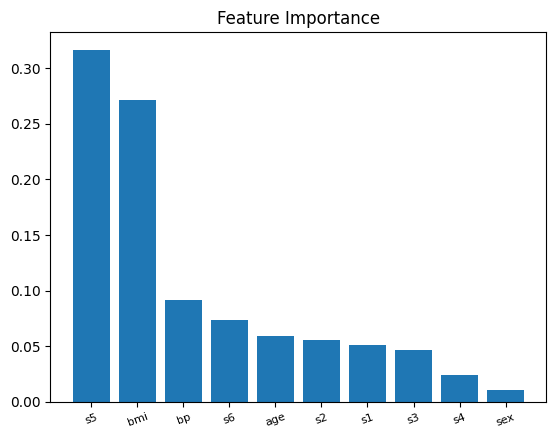

In [140]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt

# Load data
iris = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target


mod = RandomForestRegressor()
model = mod.fit(X, y)

# Calculate feature importances
importances = model.feature_importances_

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

# Rearrange feature names so they match the sorted feature importances
names = [diabetes.feature_names[i] for i in indices]

# Barplot
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), names, rotation=20, fontsize = 8)
plt.title("Feature Importance")
plt.show()

# Regression vs tree-based methods

- Trees are very easy to understand
- Trees are robust when outliers present in the data
- They can be visualised easily by plotting the tree and detect the nodes/regions
- They can easily handle qualitative predictor variables
- Trees do not have the same level of predictive accuracy as regression methods, particulary when fitted in small data size
- The interpretation of complex trees is difficult compared to regression modelling, feature importance is used instead